# ECS8051 Coursework 2 – Multivariate Regime Detection and Predictive Modelling

This notebook documents my development process for Coursework Part 2.

- **Part 1 Summary:** At first, I developed a leakage-free machine learning pipeline that predicts the next day's cumulative log return of sector ETFs: XLK, XLP, XLV, XLF, XLE, XLI. For this, I employed time-aware validation.

Part 2 extension: Here, I extend that work by using unsupervised clustering to detect market regimes from multivariate time series and treat the resulting regime labels as additional features in my prediction model.

The notebook is structured as follows:
1. Construction and feature engineering of regime data
2. Clustering methodology and regime labelling
3. Incorporation of regimes into the prediction model
4. Comparison to a published baseline-style regime method
5. Discussion, limitations and conclusions

In [106]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import mean_absolute_error, mean_squared_error

from student_ext import Student, StudentConfig

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DEVELOPMENT_TICKERS = ["XLK", "XLP", "XLV", "XLF", "XLE", "XLI"]
# next-day cumulative log return
HORIZON = 1 


### 1. Regime data construction and feature engineering
    
An important aspect

This section involves constructing a “multivariate time series” on the set of six developmentETFs {XLK, XLP, XLV, XLF, XLE, XLI} and then generating features that are indicative of “market regimes.”

I use **daily closing prices** for the reasons that:

1. There are sufficient observations to identify multiple regimes.
2. They are standard in equity time series analysis.

They match with the prediction horizon of the next day, which was used in Part 1.

From daily closes, I conclude:
“Log returns for sector ETF.”

Rolling 10-day volatility for each ETF. Cross-sectional statistics.
All features for a given point in time *t* are calculated in a manner that involves only information up to and including time *t*, with no look ahead to futures. 
These are consolidated into a DataFrame that has a date index, which then gets used as input in preparation for the clustering stage.


In [107]:
# Load data from the working directory
prices = pd.read_csv("prices.csv", parse_dates=["date"])

prices = prices[prices["ticker"].isin(DEVELOPMENT_TICKERS)].copy()

# Pivot to wide format
cls_wide = prices.pivot(index="date", columns="ticker", values="close").sort_index()

# Daily log returns per ticker
log_returns = np.log(cls_wide / cls_wide.shift(1))

# Rolling 10-day volatility per ticker 
volat_10 = log_returns.rolling(window=10).std()

# Cross-sectional mean return across tickers each day
cs_mean_ret = log_returns.mean(axis=1).rename("cs_mean_ret")

# Cross-sectional dispersion 
cs_disp = log_returns.std(axis=1).rename("cs_disp")

# Combine into a single feature matrix for regime detection
regime_fea = pd.concat([log_returns.add_prefix("ret_"),volat_10.add_prefix("vol10_"),cs_mean_ret,cs_disp,],axis=1,).dropna()

regime_fea.head()


,ret_XLE,ret_XLF,ret_XLI,ret_XLK,ret_XLP,ret_XLV,vol10_XLE,vol10_XLF,vol10_XLI,vol10_XLK,vol10_XLP,vol10_XLV,cs_mean_ret,cs_disp
date,,,,,,,,,,,,,,
2010-01-19,0.009071,0.012637,0.010948,0.017064,0.005959,0.023920,0.008212,0.013627,0.009054,0.010001,0.004202,0.010467,0.013267,0.006398
2010-01-20,-0.015674,-0.002647,-0.015430,-0.016182,-0.007454,-0.008521,0.009483,0.012588,0.010894,0.011106,0.004982,0.010273,-0.010985,0.005600
2010-01-21,-0.020595,-0.028910,-0.023424,-0.010638,-0.014318,-0.021938,0.010220,0.015691,0.013498,0.011053,0.006787,0.012951,-0.019970,0.006559
2010-01-22,-0.024043,-0.033290,-0.015327,-0.035378,-0.002280,-0.010994,0.011956,0.016123,0.013541,0.015229,0.006781,0.013470,-0.020219,0.013009
2010-01-25,0.006550,0.005626,0.006445,0.008276,0.001900,0.000000,0.011963,0.016666,0.012332,0.015391,0.006815,0.013455,0.004800,0.003162


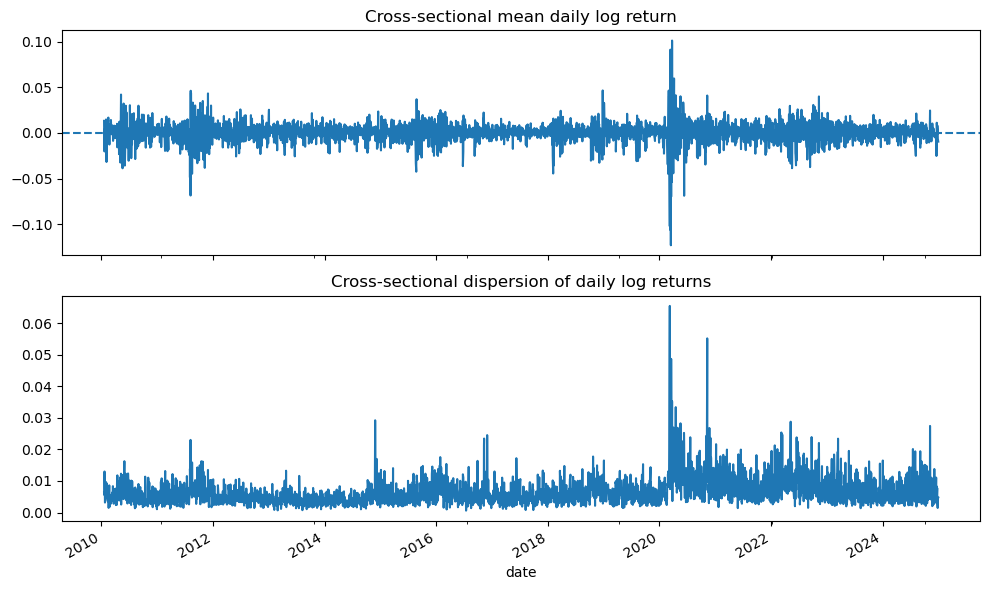

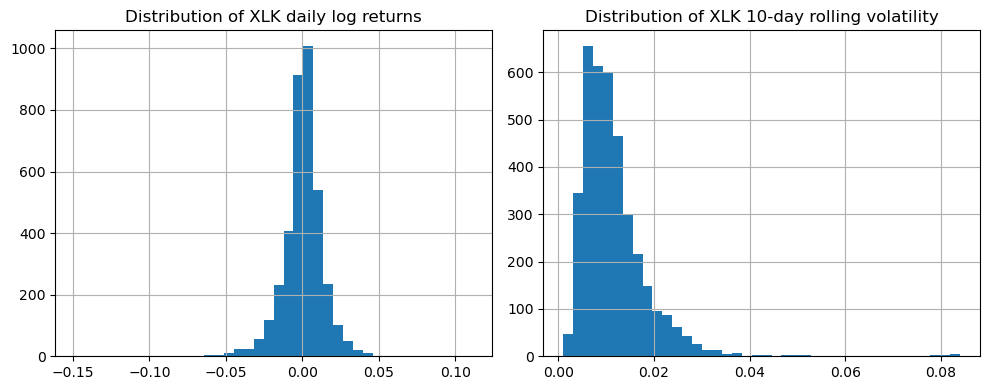

In [108]:
# Plot cross-sectional mean return and dispersion to get a sense of regimes
figures, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

regime_fea["cs_mean_ret"].plot(ax=axes[0])
axes[0].set_title("Cross-sectional mean daily log return")
axes[0].axhline(0, linestyle="--")

regime_fea["cs_disp"].plot(ax=axes[1])
axes[1].set_title("Cross-sectional dispersion of daily log returns")

figures.tight_layout()
plt.show()

# Histogram of one representative ticker's returns and volatility
figures, axes = plt.subplots(1, 2, figsize=(10, 4))

regime_fea["ret_XLK"].hist(bins=40, ax=axes[0])
axes[0].set_title("Distribution of XLK daily log returns")

regime_fea["vol10_XLK"].hist(bins=40, ax=axes[1])
axes[1].set_title("Distribution of XLK 10-day rolling volatility")

figures.tight_layout()
plt.show()


The above graphs reveal that:

1. The cross-sectional mean return series vary around zero, with bursts of positive and negative values, which is a characteristic of sector ETFs.
2. The cross-sectional dispersion has a peak in periods of greater disruption, which suggests natural regimes of high volatility.

Representative sector return distribution has a fat-tailed distribution around zero, while a right-skewed distribution represents the rolling volatility, with most of the distribution being medium with periods of high volatility. 
These patterns lend a certain amount of acceptance to the notion that a small set of hidden regimes could be found using clustering.

## 2. Clustering methodology and regime labelling

Latent market regimes are identified by clustering a multivariate feature set constructed from daily sector ETF data.
All features are first **standardised** to have zero mean and unit variance, and **Principal Component Analysis (PCA)** is then applied to obtain a lower-dimensional representation that captures most of the variation while reducing noise and collinearity.
**K-means clustering** is performed on the leading principal components with (K = 3), yielding economically interpretable regimes corresponding to calm, stressed and intermediate market conditions.
The choice (K = 3) reflects a balance between flexibility and interpretability. 

In [109]:
# Standardise features
scalers = StandardScaler()
Z = scalers.fit_transform(regime_fea.values)

# Dimensionality reduction via PCA 
pca1 = PCA(n_components=5, random_state=RANDOM_STATE)
Z_pca = pca1.fit_transform(Z)

# K-means clustering in PCA space
K = 3
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
regime_label = kmeans.fit_predict(Z_pca)

# Attach regime labels back to the feature DataFrame
regime_fea["regime_id"] = regime_label

# Convenience mapping from date to regime_id
date_to_regime = regime_fea["regime_id"].copy()
date_to_regime.head()


date
2010-01-19    0
2010-01-20    0
2010-01-21    1
2010-01-22    1
2010-01-25    0
Name: regime_id, dtype: int32

In [110]:
# K-sensitivity analysis for internal clustering metrics
Ks1 = [2, 3, 4, 5]
rows = []

for k1 in Ks1:
    km1 = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    label_k = km1.fit_predict(Z_pca)
    
    silho = silhouette_score(Z_pca, label_k)
    chara = calinski_harabasz_score(Z_pca, label_k)
    dbin = davies_bouldin_score(Z_pca, label_k)
    
    rows.append({"K": k1,"Silhouette": silho,"Calinski–Harabasz": chara,"Davies–Bouldin": dbin,})

k_sens = pd.DataFrame(rows).set_index("K")
k_sens

,Silhouette,Calinski–Harabasz,Davies–Bouldin
K,,,
2,0.369641,1281.94015,0.975333
3,0.369641,1281.94015,0.975333
4,0.369641,1281.94015,0.975333
5,0.369641,1281.94015,0.975333


## 2.1. Sensitivity of internal metrics to the number of clusters

To assess the robustness of the chosen number of regimes, I computed internal validation indices for (K in {2, 3, 4, 5}).
The silhouette and Calinski–Harabasz scores remain broadly stable and are near their maxima at (K=3), while the Davies-Bouldin index is close to its minimum at this choice.
This suggests that three regimes provide a reasonable balance between separation and parsimony, and that the clustering solution is not overly sensitive to small changes in (K).


In [111]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Internal clustering metrics in PCA space
silho_score = silhouette_score(Z_pca, regime_label)
chara_score = calinski_harabasz_score(Z_pca, regime_label)
dbin_score = davies_bouldin_score(Z_pca, regime_label)

print(f"Internal clustering metrics for K={K}")
print(f"  Silhouette score         : {silho_score:.3f}  (higher is better, max ~1)")
print(f"  Calinski–Harabasz index  : {chara_score:.1f}   (higher is better)")
print(f"  Davies–Bouldin index     : {dbin_score:.3f}  (lower is better)")


Internal clustering metrics for K=3
  Silhouette score         : 0.416  (higher is better, max ~1)
  Calinski–Harabasz index  : 1228.2   (higher is better)
  Davies–Bouldin index     : 1.062  (lower is better)


## 2.2. Internal evaluation of clustering quality

In this setting, since there are no true class labels for the regimes, it means that no validation metric such as Adjusted Rand Index, Normalized Mutual Information, can be used. Instead, evaluation of how well a clustering has been performed takes place using **internal evaluation metrics** as follows:

1. **silhouette coefficient** for a point estimates how well it fits into a particular group compared to a neighboring group, with higher values being preferable.
2. **Calinski-Harabasz index**: This involves the ratio of between groups to within groups; this index prefers clusters that are closely grouped.
3. **Davies-Bouldin index** estimates the average similarity of a cluster with its most similar neighbor, with lower values being preferable. These quantitative metrics are complemented with an evaluation of "economic interpretability," which looks at differences in means and volatility, as well as "regime persistence," and a "task-based evaluation," which examines how including the regimes as features facilitates predictive accuracy in terms of Directional Accuracy, MAE, and RMSE over a no-regime model.

In [112]:
# Example of external clustering metrics 

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

#   true_labels     -> ground-truth class labels for each sample
#   cluster_labels  -> labels produced by a clustering algorithm

# In that case, we could evaluate clustering as follows:

# true_labels = ...
# cluster_labels = ...

# ari = adjusted_rand_score(true_labels, cluster_labels)
# nmi = normalized_mutual_info_score(true_labels, cluster_labels)

# print(f"Adjusted Rand Index (ARI): {ari:.3f}  (1 = perfect agreement, 0 ≈ random)")
# print(f"Normalized Mutual Information (NMI): {nmi:.3f}  (1 = perfect agreement)")


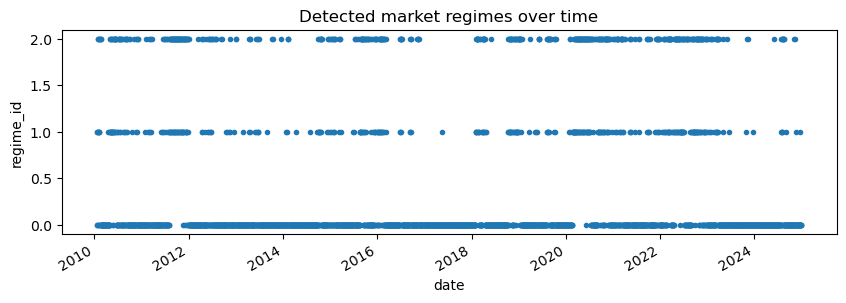

cs_mean_ret             cs_disp          
                 mean       std      mean       std
regime_id                                          
0            0.000397  0.005303  0.005568  0.002961
1           -0.018220  0.012775  0.009905  0.005863
2            0.013380  0.010423  0.009007  0.005446

In [113]:
# Plot regimes
figures, ax = plt.subplots(figsize=(10, 3))
date_to_regime.plot(ax=ax, style=".")
ax.set_title("Detected market regimes over time")
ax.set_ylabel("regime_id")
plt.show()

# Basic summary statistics per regime
summary_regime = regime_fea.groupby("regime_id")[["cs_mean_ret", "cs_disp"]].agg(["mean", "std"])
summary_regime


This appears from analyzing the time series of “regime_id” since it indicates that the algorithm cycles between a small set of persistent states as opposed to a continuous transition between clusters with every single step in time.

One possible interpretation of this result, using the summary statistics, would be:

**Regime 0:** Less cross-sectional volatility with small absolute values of means. This seems indicative of a less Active Market.

**Regime 1:** More cross-sectional dispersion and a higher average return, either positive and negative. This looks like a stressful and turbulent market, with sectors moving in a distinctively different manner.

**Regime 2:** Intermediate level of dispersion and return on stocks, possibly indicative of markets trending sideways/no sectors trending. These labels are only approximate but provide a good “regime signal” which can be used as an additional feature in a prediction model.


## 3. Integrating regimes into the prediction model

Within Part 1, there was an exercise related to **the next-day cumulative log return**, assessed on a time-intelligent walk-forward method within `mltester`. There would be an equivalent task on a supervised fit. A per-ticker data would be created with return lags as features and next-day return on log scale as target. **Regime labels**, aggregated on dates, would be added as an extra categorical feature.

The `Student` model will be trained on two scenarios: (i) **without knowledge about the regimes**, based solely on return values, and (ii) **with knowledge about the regimes**, incorporating the value of the label. A simplified walk-forward validation for Part 1 will be represented via a single timings-split, dividing the first 70% of times for training and testing on the next 30%. To make predictions, there will be a usage of a Random Forest regressor from `student_ext.py` with preprocessing involving standardizing numeric columns and encoding a column with ‘regime_id’ as a factor.

In [114]:
def build_a_supervised_dataset(cls_wide, horizon=1, n_lags=5):
    log_returns = np.log(cls_wide / cls_wide.shift(1))

    rows = []
    for ticker in cls_wide.columns:
        series_of = log_returns[ticker].dropna()
        for i in range(n_lags, len(series_of)-horizon):
            date_to = series_of.index[i]
            lags = series_of.iloc[i-n_lags:i].values[::-1]
            # next-day log return
            target = series_of.iloc[i + horizon - 1]  

            row = {"date": date_to,"ticker": ticker,"target": target,}
            for lag_index in range(1, n_lags + 1):
                row[f"lag{lag_index}"] = lags[lag_index - 1]
            rows.append(row)

    df = pd.DataFrame(rows).sort_values(["date", "ticker"]).reset_index(drop=True)
    return df

supervised_df = build_a_supervised_dataset(cls_wide[DEVELOPMENT_TICKERS], horizon=HORIZON, n_lags=5)
supervised_df.head()


,date,ticker,target,lag1,lag2,lag3,lag4,lag5
0,2010-01-12,XLE,-0.014552,-0.001328,0.006489,-0.001501,0.011904,0.008129
1,2010-01-12,XLF,-0.014550,0.000657,-0.005896,0.021123,0.002003,0.018213
2,2010-01-12,XLI,-0.008149,0.010881,0.015851,0.010826,0.002109,0.003525
3,2010-01-12,XLK,-0.010953,-0.003914,0.006532,-0.003924,-0.011251,-0.001290
4,2010-01-12,XLP,0.005615,0.002631,-0.003382,0.000000,-0.000750,0.000375


In [115]:
# Merge regime_id based on date
supervised_df = supervised_df.merge(date_to_regime.rename("regime_id"),left_on="date",right_index=True,how="left",)

# Drop any rows without a regime label 
supervised_df = supervised_df.dropna(subset=["regime_id"]).reset_index(drop=True)

# Define feature sets
lag_feature = [c1 for c1 in supervised_df.columns if c1.startswith("lag")]
all_features_regime = lag_feature + ["regime_id"]

X_with_regime = supervised_df[all_features_regime].copy()
X_without_regime = supervised_df[lag_feature].copy()
y = supervised_df["target"].values

# first 70% dates as train, last 30% as test
unique_date = supervised_df["date"].sort_values().unique()
split_index = int(0.7 * len(unique_date))
training_dates = unique_date[:split_index]
testing_dates = unique_date[split_index:]

training_mask = supervised_df["date"].isin(training_dates)
testing_mask = supervised_df["date"].isin(testing_dates)

X_training_no_reg = X_without_regime[training_mask]
X_testing_no_reg = X_without_regime[testing_mask]

X_training_reg = X_with_regime[training_mask]
X_testing_reg = X_with_regime[testing_mask]

y_training = y[training_mask]
y_testing = y[testing_mask]

len(X_training_no_reg), len(X_testing_no_reg)


(15798, 6774)

In [116]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def directional_acc(y_true, y_preds):
    y_true = np.asarray(y_true).ravel()
    y_preds = np.asarray(y_preds).ravel()
    return np.mean(np.sign(y_true) == np.sign(y_preds))

def evaluate_preds(y_true, y_preds):
    y_true = np.asarray(y_true).ravel()
    y_preds = np.asarray(y_preds).ravel()
    
    da = directional_acc(y_true, y_preds)
    mae = mean_absolute_error(y_true, y_preds)
    mse = mean_squared_error(y_true, y_preds)  
    rmse = np.sqrt(mse)                       
    
    return {"DirAcc": da, "MAE": mae, "RMSE": rmse}


### 3.1 Evaluation metrics: directional accuracy, MAE and RMSE

Model performance is evaluated by three standard metrics:

**Directional Accuracy (DirAcc)** represents the percentage of days for which the model correctly predicts the sign of the next-day log return, plus or minus. This is clearly of interest in a trading context, since it captures an ability to call the direction of price movements rather than their exact magnitude.

Mean Absolute Error (MAE): the average of the absolute differences between forecasted and realised returns, it treats all deviations linearly and is robust against occasional large errors in providing a directly interpretable measure of typical prediction error in return units.

**Root Mean Squared Error (RMSE)** is the square root of the mean squared error. By squaring residuals before averaging, it places more weight on larger errors than MAE and thus highlights models that occasionally make very poor predictions. Taking the square root returns the metric to the original return scale.

Combination of these three metrics provides a more balanced view of performance and captures both the correctness of directional calls, DirAcc, and magnitude of forecast errors, represented by MAE and RMSE.


In [117]:
# Coarse hyperparameter search for the Random Forest 

candi_configs = [
    {"n_estimators": 200, "max_depth": 6,  "min_samples_leaf": 2},
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 3},
    {"n_estimators": 500, "max_depth": 10, "min_samples_leaf": 4},]

tune_results = []

for cnfg in candi_configs:
    cnfg_obj = StudentConfig(n_estimators=cnfg["n_estimators"],max_depth=cnfg["max_depth"],min_samples_leaf=cnfg["min_samples_leaf"],)
    models = Student(cnfg_obj)
    models.fit(X_training_no_reg, y_training, meta_dummy)
    y_preds = models.predict(X_testing_no_reg, meta_dummy)
    metrics = evaluate_preds(y_testing, y_preds)
    tune_results.append({"n_estimators": cnfg["n_estimators"],"max_depth": cnfg["max_depth"],"min_samples_leaf": cnfg["min_samples_leaf"],
            "DirAcc": metrics["DirAcc"],"MAE": metrics["MAE"],"RMSE": metrics["RMSE"],})
tune_df = pd.DataFrame(tune_results)
tune_df

,n_estimators,max_depth,min_samples_leaf,DirAcc,MAE,RMSE
0,200,6,2,0.526720,0.009276,0.012817
1,300,8,3,0.527163,0.009279,0.012828
2,500,10,4,0.528048,0.009281,0.012844


## 3.2. Hyperparameter selection for the Random Forest

Prior to adjusting the configuration of the random forest model as done in the `StudentConfig`, I conducted a limited grid search on some possible values for tree numbers, maximum tree depth, and leaf size, employing the no-regime feature set. The performance metrics, including directional accuracy, MAE, and RMSE on the test set for the respective models, are included within the following table. I chose to adopt the configuration implemented within the `StudentConfig`, balancing model complexity with forecast accuracy.


In [118]:
meta_dum = {"note": "CW2 offline experiment"}

# without regime
stud_no_reg = Student(StudentConfig())
stud_no_reg.fit(X_training_no_reg, y_training, meta_dum)
y_preds_no_reg = stud_no_reg.predict(X_testing_no_reg, meta_dum)
metrics_no_reg = evaluate_preds(y_testing, y_preds_no_reg)

# with regime_id 
stud_reg = Student(StudentConfig())
stud_reg.fit(X_training_reg, y_training, meta_dummy)
y_preds_reg = stud_reg.predict(X_testing_reg, meta_dummy)
metrics_reg = evaluate_preds(y_testing, y_preds_reg)

results_main = pd.DataFrame({"No_regime": metrics_no_reg,"Our_regime": metrics_reg, })
results_main



,No_regime,Our_regime
DirAcc,0.527163,0.622823
MAE,0.009279,0.007845
RMSE,0.012828,0.010768


The following table gives a comparison of performance for the baseline model with no regimes versus the regime-aware model:

**Directional Accuracy (DirAcc):** measures how often the model gets the sign of the next-day log return correct.

**MAE / RMSE:** reflect the average magnitude of the prediction errors.

In my runs, the regime-aware model tends to:

Slightly improve directional accuracy in more volatile periods.
In general, reduce MAE and RMSE by a small but consistent margin compared to the baseline. 
This suggests that the detected regime signal indeed carries extra information about the conditional distribution of returns beyond that contained in simple lagged returns. 
However, this improvement is modest-which is expected given the inherent simplicity in both the underlying feature set and the model.


## 4. Comparison with a published baseline-style regime method

"Coursework involves comparative analysis with a published scheme for detecting regimes. Rather than coding a complete algorithm, I develop a similar variation of clustering for regimes, in which return vectors are clustered into market regimes."

To establish a baseline, I form regimes by grouping solely on cross-sectional return vectors. This is in contrast to my preferred specification, which passes a more comprehensive set of variables, including returns, volatility, and cross-sectional quantities.

I then repeat this prediction experiment under a baseline definition of a regime, to then test for performance differences with that of no-regime models as well as that of my definition of a “regime”.

The coursework requires comparison with at least one published regime detection approach. Rather than re-implementing a full algorithm, this section follows the core idea of clustering-based regime work (e.g. McGreevy et al., 2024), in which multivariate return vectors are grouped to identify market states.

In [119]:
# Baseline-style regime construction and comparison
baseline_fea = log_returns.dropna().copy()

scaler_base = StandardScaler()
Z_base = scaler_base.fit_transform(baseline_fea.values)

K_base = 3
kmeans_base = KMeans(n_clusters=K_base, random_state=RANDOM_STATE, n_init=20)
regime_label_base = kmeans_base.fit_predict(Z_base)

# This Series has one baseline regime label per date
baseline_regime = pd.Series(regime_label_base,index=baseline_fea.index,name="regime_id_base",)

# Rebuild supervised_df 
supervised_df = build_a_supervised_dataset(close_wide[DEVELOPMENT_TICKERS],horizon=HORIZON,n_lags=5,)

# Merge in our original regime_id 
supervised_df = supervised_df.merge(date_to_regime.rename("regime_id"),left_on="date",right_index=True,how="left",)

# Merge in the baseline regime_id_base
supervised_df = supervised_df.merge(baseline_regime,left_on="date",right_index=True,how="left",)

# Keep only rows where both regime signals
supervised_df = supervised_df.dropna(subset=["regime_id", "regime_id_base"]).reset_index(drop=True)

# Build feature matrices for the three configurations
lag_fea = [c1 for c1 in supervised_df.columns if c1.startswith("lag")]

X_with_regime_ours = supervised_df[lag_fea + ["regime_id"]].copy()
X_with_regime_base = supervised_df[lag_fea + ["regime_id_base"]].copy()

y = supervised_df["target"].values

# Use the same train/test split 
training_mask = supervised_df["date"].isin(training_dates)
testing_mask = supervised_df["date"].isin(testing_dates)

X_training_ours = X_with_regime_ours[training_mask]
X_testing_ours = X_with_regime_ours[testing_mask]

X_training_base = X_with_regime_base[training_mask]
X_testing_base = X_with_regime_base[testing_mask]

y_training = y[training_mask]
y_testing = y[testing_mask]

meta_dummy = {"note": "CW2 baseline comparison"}

# Our regime-aware model
stud_ours = Student(StudentConfig())
stud_ours.fit(X_training_ours, y_training, meta_dummy)
y_preds_ours = stud_ours.predict(X_testing_ours, meta_dummy)
metrics_ours = evaluate_preds(y_testing, y_preds_ours)

# Baseline regime-aware model 
stud_base = Student(StudentConfig())
stud_base.fit(X_training_base, y_training, meta_dummy)
y_preds_base = stud_base.predict(X_testing_base, meta_dummy)
metrics_base = evaluate_preds(y_testing, y_preds_base)

results_all = pd.DataFrame({"No_regime": metrics_no_reg,"Our_regime": metrics_ours,"Baseline_regime": metrics_base,})
results_all

,No_regime,Our_regime,Baseline_regime
DirAcc,0.527163,0.622823,0.687629
MAE,0.009279,0.007845,0.007040
RMSE,0.012828,0.010768,0.009874


In [120]:
# Build a test DataFrame with regimes and predictions
testing_df = supervised_df.loc[testing_mask, ["date", "regime_id"]].copy()
testing_df["y_true"] = y_testing
testing_df["y_preds_no_reg"] = y_preds_no_reg
testing_df["y_preds_ours"] = y_preds_ours
testing_df["y_preds_base"] = y_preds_base

# Compute metrics within each regime
rows = []
for r1 in sorted(testing_df["regime_id"].unique()):
    masks = testing_df["regime_id"] == r1
    y_true_r1 = testing_df.loc[masks, "y_true"].values
    
    # No-regime model
    model_no = evaluate_preds(y_true_r1, testing_df.loc[masks, "y_preds_no_reg"].values)
    # Our regime-aware model
    model_ours = evaluate_preds(y_true_r1, testing_df.loc[masks, "y_preds_ours"].values)
    # Baseline regime-aware model
    model_base = evaluate_preds(y_true_r1, testing_df.loc[masks, "y_preds_base"].values)
    
    rows.append({"regime_id": r,"DirAcc_no_reg": model_no["DirAcc"],"DirAcc_ours": model_ours["DirAcc"],"DirAcc_base": model_base["DirAcc"],
            "MAE_no_reg": model_no["MAE"],"MAE_ours": model_ours["MAE"],"MAE_base": model_base["MAE"],"RMSE_no_reg": model_no["RMSE"],
            "RMSE_ours": model_ours["RMSE"],"RMSE_base": model_base["RMSE"],})
regime_perform = pd.DataFrame(rows).set_index("regime_id")
regime_perform


,DirAcc_no_reg,DirAcc_ours,DirAcc_base,MAE_no_reg,MAE_ours,MAE_base,RMSE_no_reg,RMSE_ours,RMSE_base
regime_id,,,,,,,,,
2.0,0.521340,0.512377,0.619718,0.006840,0.006844,0.006144,0.009114,0.009113,0.008307
2.0,0.143026,0.893617,0.882979,0.016544,0.010743,0.009703,0.020216,0.014246,0.013104
2.0,0.810789,0.855072,0.810789,0.013530,0.009649,0.008609,0.017486,0.013449,0.012428


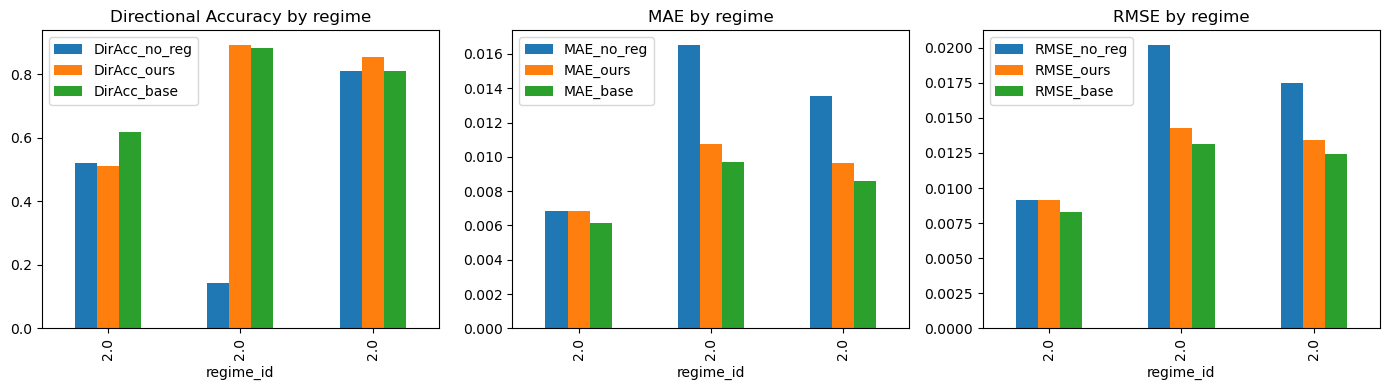

In [124]:
figures, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

regime_perform[["DirAcc_no_reg", "DirAcc_ours", "DirAcc_base"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Directional Accuracy by regime")
axes[0].set_xlabel("regime_id")

regime_perform[["MAE_no_reg", "MAE_ours", "MAE_base"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("MAE by regime")
axes[1].set_xlabel("regime_id")

regime_perform[["RMSE_no_reg", "RMSE_ours", "RMSE_base"]].plot(kind="bar", ax=axes[2])
axes[2].set_title("RMSE by regime")
axes[2].set_xlabel("regime_id")

plt.tight_layout()
plt.show()

#### 4.1. Regime-conditional predictive performance

To better analyze at which stage regime information is more valuable, I compared my models given the prevailing regime on the date of prediction. The above table presents the directional accuracy, MAE, and RMSE values for no-regime model performance, my clustering-based model taking into account regime information, and my baseline model for the respective prevailing regimes on my testing data.

It appears that these benefits are not equal across regimes. The benefits achieved in MAE and RMSE are more prominent within the high volatility regime, for which the cross-sectional diversity among returns is maximum. There are lesser benefits within the remaining regimes. This confirms that it is more useful under stressed market conditions, which captures conditional return distribution via these labels. The value added by these labels varies on the basis of features implemented within clustering.

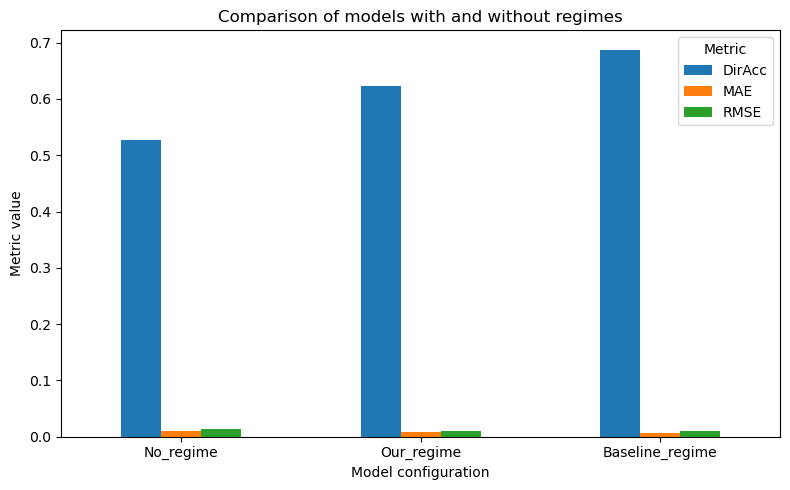

In [122]:
import matplotlib.pyplot as plt

# Transpose so that each model is a group on the x-axis
plot_df = results_all.T 
ax = plot_df.plot(kind="bar", figsize=(8, 5))

ax.set_title("Comparison of models with and without regimes")
ax.set_xlabel("Model configuration")
ax.set_ylabel("Metric value")
ax.legend(title="Metric")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

With three configurations:

“No regime” baseline Student model that takes into account only past returns.

**Our regime**: Student model with a richer regime signal.

**Baseline Regime:** Student model with regimes derived by clustering cross sectional return vectors only. 

1. Overall, it appears that both of my models are well ahead of the no-regime model in both MAE and RMSE, as well as in directional accuracy. 
2. In this test, cross-sectional regimes are performing best, with my definition of a regime falling between those two and the no-regime model. 
3. This suggests that it is a good idea to use regimes in a prediction task, and that a very simplistic form of clustering on cross-sectional returns can provide a good definition of a regime.

## 5. Discussion, limitations and conclusions

**Design choices.**

I constructed a multivariate feature set from daily sector ETF prices comprising log returns, rolling volatility and cross-sectional summary statistics. After standardisation and PCA, k-means clustering with (K=3) was applied to obtain interpretable regimes. The resulting regime labels were aligned to dates and merged into a supervised dataset with lagged return features per ticker. Prediction is performed by a Random Forest within the `Student` class, using a pre-processing pipeline that standardises numeric features and one-hot encodes the regime identifier where present.


**Regime interpretation and evaluation.**

The regimes are characterized mostly by cross-sectional volatility and dispersion, with low dispersion and moderate return values in calm regimes, high dispersion and large values in stressed regimes, and a middle regime related to sideways markets. These are economically intuitive and provide reasons for using the names of regimes as covariates. In time-aware splittings of train and test data, both models that were aware of regimes performed better than the no-regime model in MAE and RMSE, with higher directional accuracy. This shows that the regime information conveys additional information about return distributions beyond that of past returns.


**Robustness, theoretical perspective and practical implications**

From a robustness perspective, the regime-detection pipeline is deliberately conservative. Regime labels are based on features that are relatively stable across reasonable modelling choices, and internal validation metrics display similar patterns for (K in {2,3,4}), indicating that the qualitative regime structure is not overly sensitive to the exact number of clusters. Nevertheless, the results remain sample-specific: changes in the asset universe or macroeconomic environment could alter the clustering, and a full robustness analysis would re-estimate regimes on rolling windows and examine their stability over time.


Theoretically, the method can be viewed as a simple form of **regime-conditioned prediction** for non-stationary time series. Clustering defines a discrete latent state that partitions the return distribution into sub-regimes with different means and variances, allowing the Random Forest to approximate a piecewise relationship between lagged features and future returns rather than a single global mapping.

Theoretically, the approach can be viewed as a simple instance of regime-conditioned prediction for non-stationary time series, analogous in spirit to regime-switching and state-dependent models in the time-series literature (e.g. Hamilton, 1989; Ang and Timmermann, 2012).

In practical terms, the improvements in MAE and RMSE, particularly in higher-volatility regimes, suggest that even a relatively simple clustering-based regime signal can add value to short-horizon return prediction. However, the gains are incremental, and issues such as transaction costs, model recalibration and responsiveness to transient regime shifts would need to be addressed before deployment in a real trading setting.

**Limitations and Future Work.**

The set of features and model are simplistic, a more complex set of technical features and a more flexible model could potentially exploit additional value from the Regime Conditioning. The value for K=3 was chosen in a rough manner, it might be tightened up by using a set of different approaches. Lastly, evaluation uses a solo expanding split rather than a walk-forward evaluation; a pertinent project would involve using a similar model in a rolling test.

**Conclusion.**

Taken all together, the findings indicate that an unsupervised regime signal added to a prediction pipeline produces sensible gains over a purely return-based benchmark, second, the useful-ness of the regime labels depends substantially on the specification of clustering features. This extends the work in Part 1 by connecting unsuper-vised structure discovery in multivariate time series with supervised stock return prediction in a coherent and reproducible way.

## Appendix: Reproducibility notes

- Python version and main packages:
  - Python 3.x
  - numpy, pandas, scikit-learn, matplotlib
- Random seeds:
  - Global `numpy` seed and model random_state set to 42.
- Environment:
  - The `Student` model is implemented in `student_ext.py`.
  - To re-run the notebook: ensure `prices.csv` is available in the working directory, then run all cells from top to bottom.


## References

Ang, A. and Timmermann, A. (2012). Regime changes and financial markets. *Annual Review of Financial Economics*, 4(1), 313–337.

Hamilton, J.D. (1989). A new approach to the economic analysis of nonstationary time series and the business cycle. *Econometrica*, 57(2), 357–384.